# Diabetes Prediction — Exploratory Data Analysis and Classification


---

## 2. Data Loading

We start by importing the libraries we will use throughout the project and loading the
dataset into a pandas DataFrame.

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Imbalanced-learn (for handling class imbalance without data leakage)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Plot / display settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load the dataset
df = pd.read_csv("diabetes_prediction_dataset.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 100000 rows, 9 columns


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 3. Basic Data Inspection

Before doing anything else, we inspect the structure of the data: column types, summary
statistics, missing values, and duplicate rows.

In [3]:
# Structure of the dataset: column names, dtypes, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [4]:
# Summary statistics for numeric columns
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
# Summary statistics for categorical columns
df.describe(include="object")

/tmp/ipykernel_675/1817281860.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,gender,smoking_history
count,100000,100000
unique,3,6
top,Female,No Info
freq,58552,35816


In [6]:
# Check for missing values in every column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)
print(f"\nTotal missing values in dataset: {missing_values.sum()}")

Missing values per column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Total missing values in dataset: 0


In [7]:
# Check for duplicate rows
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

Number of duplicate rows: 3854


**Insight:** The dataset has no missing values, so no imputation is required. However,
it does contain a number of duplicate rows — these are identical patient records that
would otherwise inflate certain patterns in the data and could leak identical rows into
both the train and test sets, so we remove them next.

In [8]:
# Remove duplicate rows (keep the first occurrence)
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Removed {before - after} duplicate rows.")
print(f"New dataset shape: {df.shape}")

Removed 3854 duplicate rows.
New dataset shape: (96146, 9)


## 4. Exploratory Data Analysis (EDA)

We now explore the distribution of the target variable, categorical features, numeric
features, and the relationships between variables.

### 4.1 Target Variable Distribution

Class counts:
 diabetes
0    87664
1     8482
Name: count, dtype: int64

Class percentages:
 diabetes
0    91.18
1     8.82
Name: proportion, dtype: float64


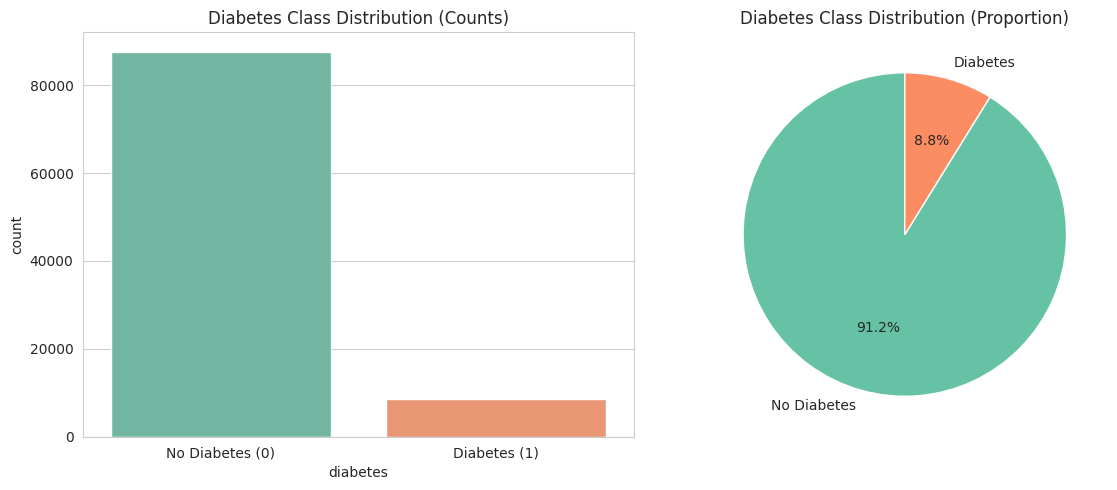

In [9]:
target_counts = df["diabetes"].value_counts()
target_pct = df["diabetes"].value_counts(normalize=True) * 100

print("Class counts:\n", target_counts)
print("\nClass percentages:\n", target_pct.round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="diabetes", data=df, hue="diabetes", palette="Set2", legend=False, ax=ax[0])
ax[0].set_title("Diabetes Class Distribution (Counts)")
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])

ax[1].pie(target_counts, labels=["No Diabetes", "Diabetes"], autopct="%1.1f%%",
          colors=sns.color_palette("Set2"), startangle=90)
ax[1].set_title("Diabetes Class Distribution (Proportion)")

plt.tight_layout()
plt.show()

**Insight:** The target variable is **heavily imbalanced** — the large majority of
patients do not have diabetes. If we train a model without addressing this, it can
achieve high accuracy simply by predicting the majority class for almost everyone, while
completely failing to identify diabetic patients (low recall for the positive class).
This is exactly the problem the SMOTE + RandomUnderSampler pipeline later in this
notebook is designed to correct.

### 4.2 Categorical Features

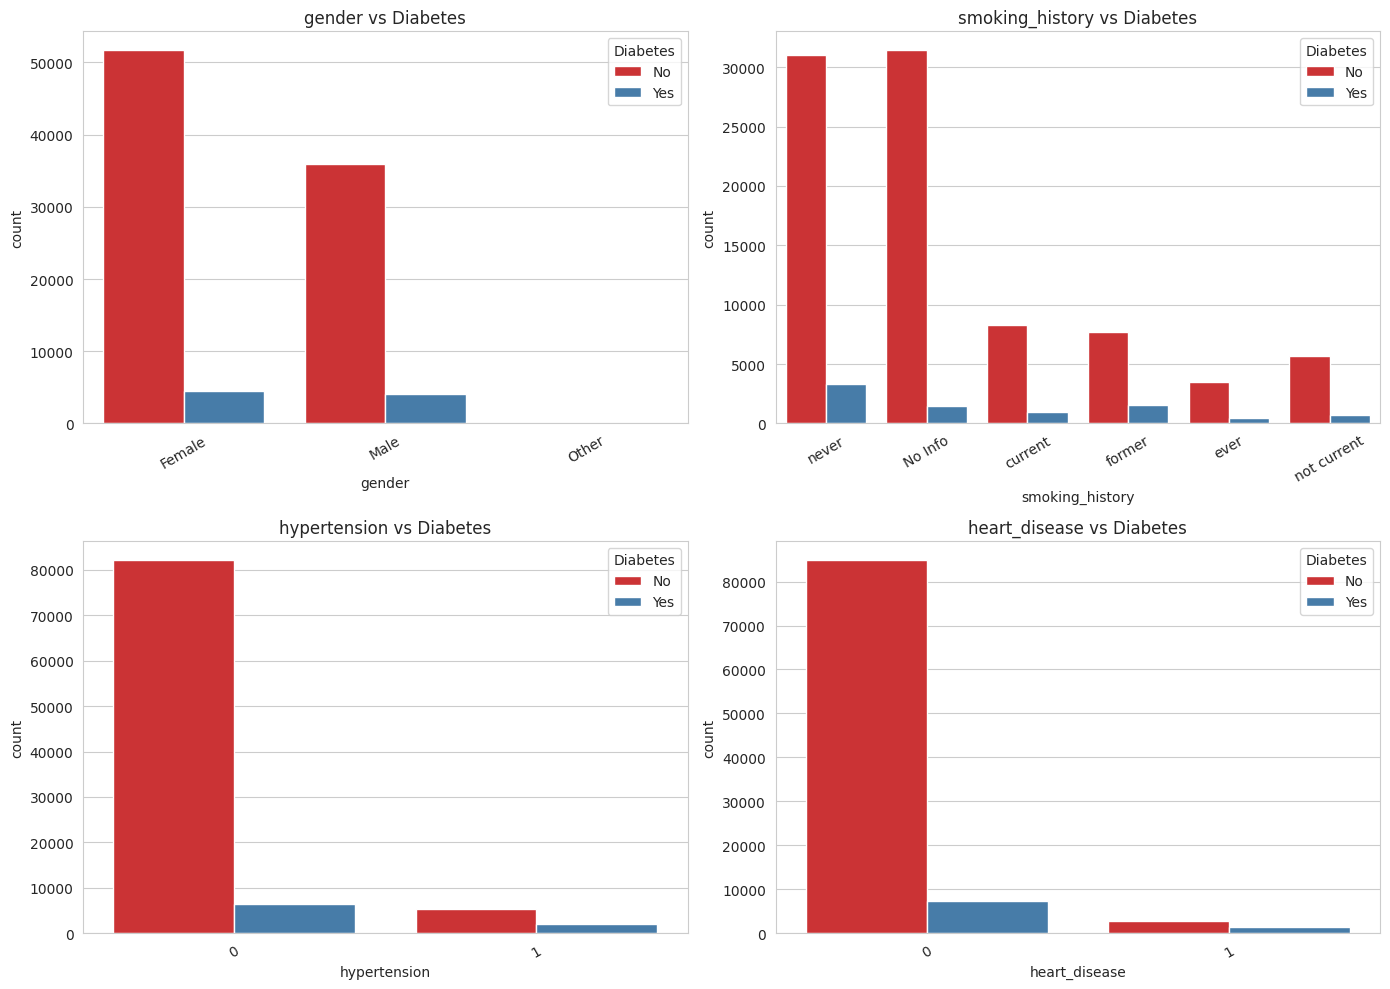

In [10]:
categorical_plot_cols = ["gender", "smoking_history", "hypertension", "heart_disease"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_plot_cols):
    sns.countplot(x=col, data=df, hue="diabetes", palette="Set1", ax=axes[i])
    axes[i].set_title(f"{col} vs Diabetes")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(title="Diabetes", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

**Insight:**
- `gender`: Both genders appear in large numbers; the diabetic proportion looks broadly
  similar across genders, with a very small number of "Other" records.
- `smoking_history`: A large share of records fall under "No Info" / "never", which limits
  how much this feature alone can separate the classes, though current/former smokers show
  a somewhat higher diabetic share.
- `hypertension` and `heart_disease`: Both are strongly skewed toward "0" (absence of the
  condition), but patients with hypertension or heart disease show a **noticeably higher
  proportion of diabetes**, suggesting these are useful predictive signals.

### 4.3 Numeric Features — Histograms

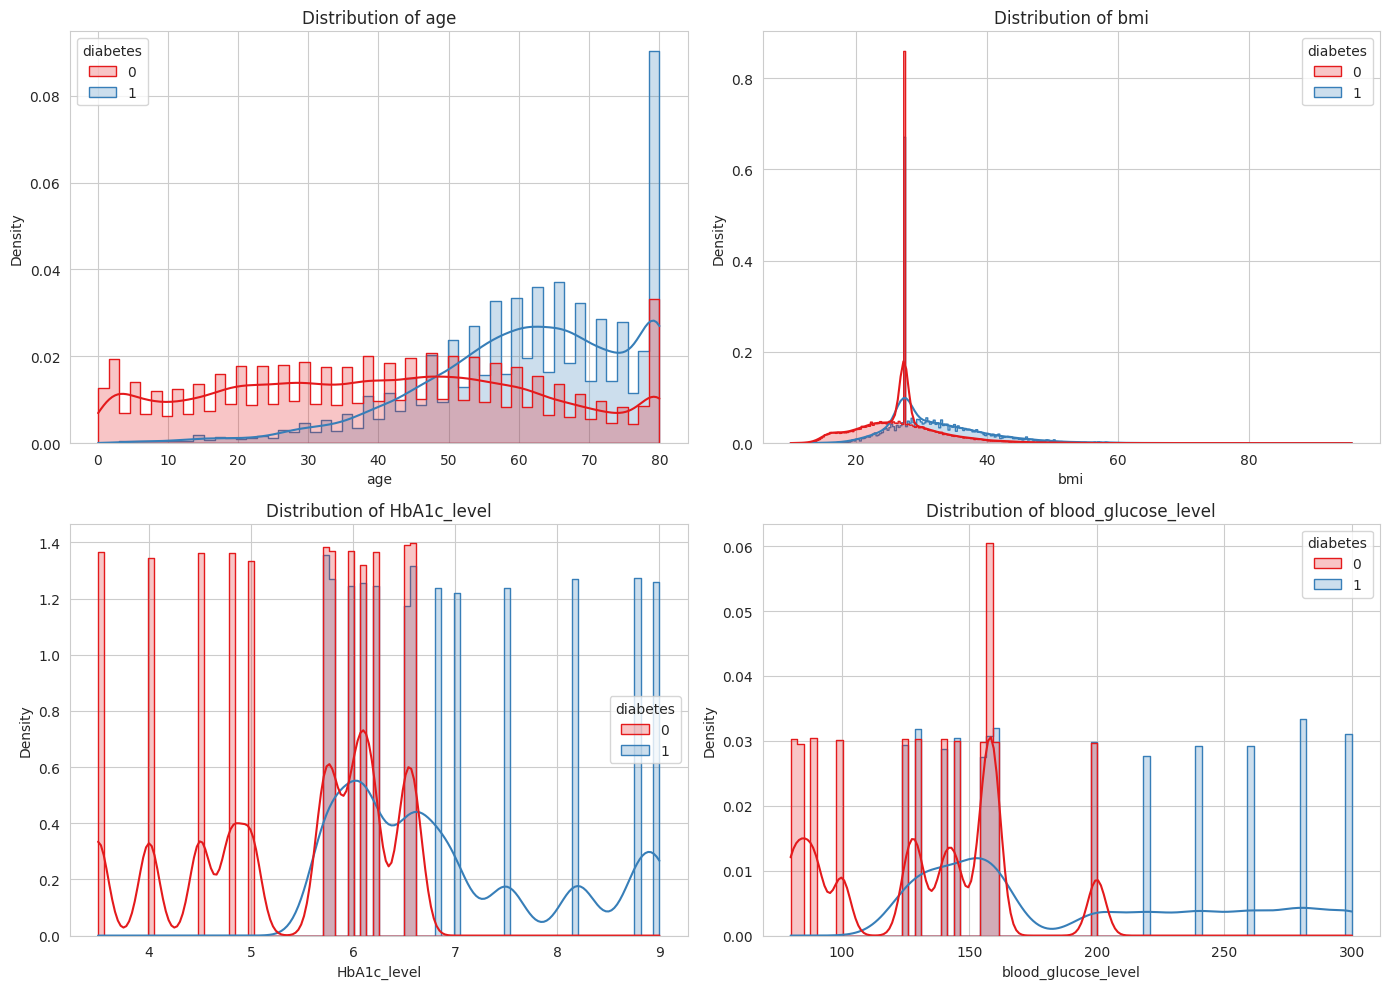

In [11]:
numeric_plot_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_plot_cols):
    sns.histplot(data=df, x=col, hue="diabetes", kde=True, palette="Set1",
                 element="step", stat="density", common_norm=False, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### 4.4 Numeric Features — Boxplots

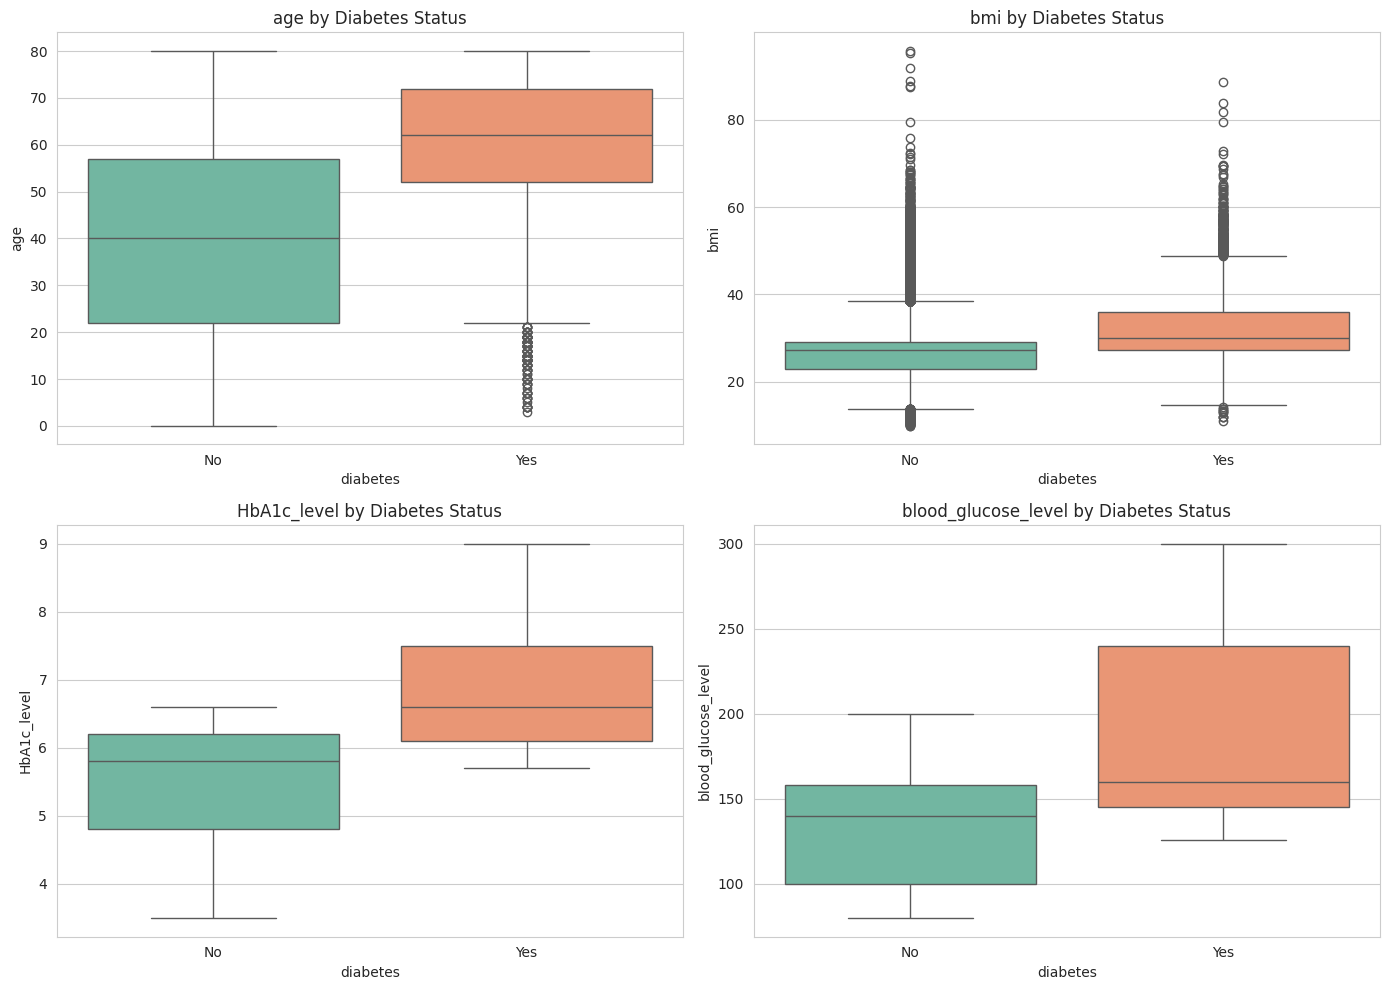

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_plot_cols):
    sns.boxplot(x="diabetes", y=col, data=df, hue="diabetes", palette="Set2",
                legend=False, ax=axes[i])
    axes[i].set_title(f"{col} by Diabetes Status")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No", "Yes"])

plt.tight_layout()
plt.show()

**Insight:**
- `age`: Diabetic patients skew notably older than non-diabetic patients.
- `bmi`: Diabetic patients tend to have a higher BMI on average, consistent with known
  clinical risk factors for Type 2 diabetes.
- `HbA1c_level` and `blood_glucose_level`: These show the clearest separation between the
  two classes — diabetic patients cluster at visibly higher values for both, which makes
  sense clinically since these are direct diagnostic markers of diabetes.

### 4.5 Correlation Analysis

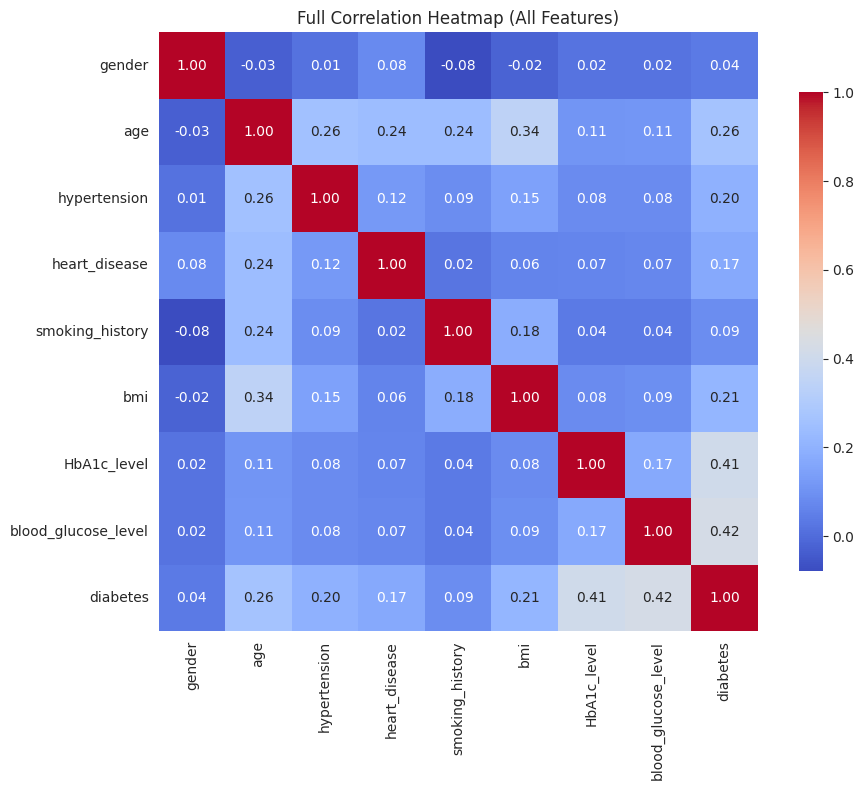

In [13]:
# Encode categorical columns temporarily (numeric codes) purely for correlation exploration
corr_df = df.copy()
corr_df["gender"] = corr_df["gender"].astype("category").cat.codes
corr_df["smoking_history"] = corr_df["smoking_history"].astype("category").cat.codes

corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Full Correlation Heatmap (All Features)")
plt.tight_layout()
plt.show()

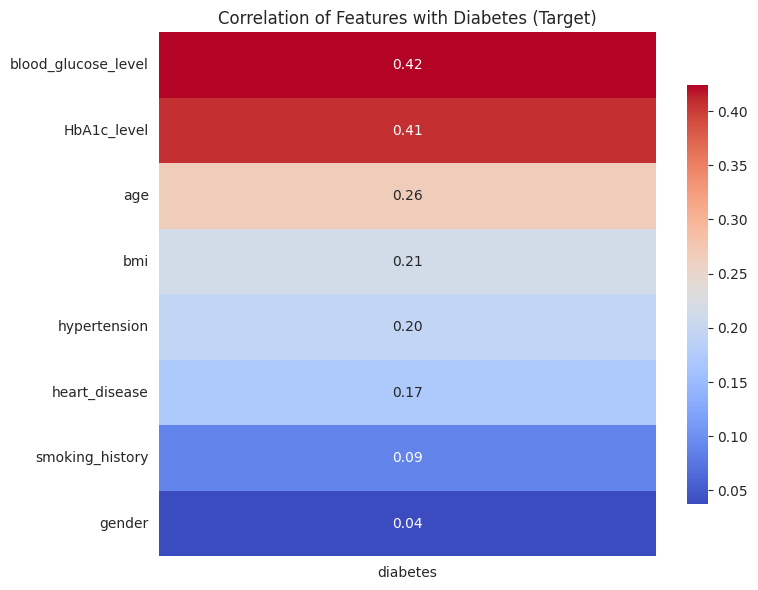

Features ranked by correlation with diabetes:
blood_glucose_level    0.424336
HbA1c_level            0.406408
age                    0.264927
bmi                    0.214932
hypertension           0.195710
heart_disease          0.170711
smoking_history        0.088471
gender                 0.037613
Name: diabetes, dtype: float64


In [14]:
# Correlation of every feature with the target only, sorted
target_corr = corr_matrix["diabetes"].drop("diabetes").sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(target_corr.to_frame(), annot=True, fmt=".2f", cmap="coolwarm",
            cbar_kws={"shrink": 0.8})
plt.title("Correlation of Features with Diabetes (Target)")
plt.tight_layout()
plt.show()

print("Features ranked by correlation with diabetes:")
print(target_corr)

**Insight:** `HbA1c_level` and `blood_glucose_level` show the **strongest positive
correlation** with the diabetes target, followed by `age` and `bmi`. `hypertension` and
`heart_disease` show weaker but still positive correlations. Encoded `gender` and
`smoking_history` show the weakest linear correlation with the target — this doesn't mean
they are useless (a tree-based model can still exploit non-linear interactions), but it
does suggest the clinical/lab measurements will likely dominate model decisions.

---

## 5. Preprocessing

### Why we need a preprocessing pipeline
Our features are a mix of **numeric** measurements (age, BMI, HbA1c, glucose) and
**categorical** attributes (gender, smoking history). Most scikit-learn models require
purely numeric input, and models such as Logistic Regression and KNN are sensitive to the
*scale* of numeric features. A `ColumnTransformer` lets us apply the right transformation
to the right column type in a single, reusable object:

- `StandardScaler` standardizes numeric features (mean 0, standard deviation 1) so that
  no single feature dominates due to its scale (e.g. `blood_glucose_level` ranges in the
  hundreds while `HbA1c_level` ranges from about 3-9).
- `OneHotEncoder(handle_unknown="ignore")` converts categorical text values into binary
  columns, and safely ignores any category value at prediction time that wasn't seen
  during training instead of throwing an error.

Wrapping all of this inside a `Pipeline` also guarantees that the **same** fitted
transformation (fitted only on training data) is applied consistently to the test data,
which prevents **data leakage**.

In [15]:
# Define feature groups
categorical_cols = ["gender", "smoking_history"]
numeric_cols = ["age", "hypertension", "heart_disease", "bmi", "HbA1c_level", "blood_glucose_level"]

target_col = "diabetes"

X = df[categorical_cols + numeric_cols]
y = df[target_col]

print("Feature columns:", X.columns.tolist())
print("Target:", target_col)

Feature columns: ['gender', 'smoking_history', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Target: diabetes


### Train / Test Split (before any resampling)

We split the data into training and test sets **first**, before applying any resampling
technique. This is critical: if we resampled (e.g. with SMOTE) before splitting, synthetic
samples derived from a test-set record could end up in the training set, or a duplicated
record could appear in both sets -- this is a classic form of **data leakage** that makes
test performance look artificially good. We use `stratify=y` to preserve the same class
ratio in both the train and test sets.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")
print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set size: 76916 rows
Test set size: 19230 rows

Training set class distribution:
diabetes
0    0.912
1    0.088
Name: proportion, dtype: float64

Test set class distribution:
diabetes
0    0.912
1    0.088
Name: proportion, dtype: float64


In [17]:
# ColumnTransformer: apply StandardScaler to numeric columns and OneHotEncoder to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Why Class Imbalance Matters

Recall from the EDA that diabetic patients make up a small minority of the dataset. If we
train a classifier directly on this imbalanced data:

- The model can achieve **high accuracy** simply by predicting "no diabetes" for almost
  everyone, since that is correct most of the time.
- However, this makes the model clinically useless, because it will have **very low
  recall** for the diabetic class -- meaning it fails to flag most patients who actually
  have diabetes. In a healthcare context, missing a true positive (a false negative) is
  usually far more costly than a false alarm.

To address this, we build an `imblearn` pipeline that combines:
- **SMOTE (Synthetic Minority Over-sampling Technique):** creates synthetic examples of
  the minority (diabetic) class by interpolating between existing minority samples, rather
  than crudely duplicating rows.
- **RandomUnderSampler:** randomly removes some samples from the majority (non-diabetic)
  class to further balance the classes without over-relying purely on synthetic data.

Combining both moderates the extremes of pure oversampling (risk of overfitting to
synthetic patterns) and pure undersampling (risk of discarding useful majority-class
information). Crucially, we only ever apply this resampling to the **training data**
(and, during cross-validation, only within each training fold) -- the test set always
reflects the real, original class distribution so that our evaluation metrics are
realistic.

In [18]:
# Build the imbalance-handling step: SMOTE followed by RandomUnderSampler
# sampling_strategy=0.5 means: after SMOTE, the minority class will have 50% as many
# samples as the majority class; RandomUnderSampler then trims the majority class down
# to match, producing a balanced 1:1 training set.
smote = SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE)
under_sampler = RandomUnderSampler(sampling_strategy=1.0, random_state=RANDOM_STATE)

print("Resampling steps defined:")
print(smote)
print(under_sampler)

Resampling steps defined:
SMOTE(random_state=42, sampling_strategy=0.5)
RandomUnderSampler(random_state=42, sampling_strategy=1.0)


## 6. Helper Functions

To keep the modeling code clean and avoid repetition, we define a few reusable helper
functions: one to compute and print a full set of evaluation metrics, one to plot a
confusion matrix, and one to build the final model comparison table.

In [19]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Fit-free evaluation helper: assumes `model` is already fitted.
    Computes training and test metrics and returns them as a dictionary.
    """
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # ROC-AUC needs predicted probabilities (or decision function) for the positive class
    try:
        y_test_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_test_proba)
    except AttributeError:
        y_test_proba = None
        roc_auc = np.nan

    metrics = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1-Score": f1_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc,
    }

    print(f"--- {model_name} ---")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")
    print()

    return metrics, y_test_pred, y_test_proba


def plot_conf_matrix(y_true, y_pred, model_name="Model"):
    """Plot a labeled confusion matrix heatmap for a single model."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


def build_comparison_table(results_list):
    """Build a sorted comparison DataFrame from a list of metric dictionaries."""
    comp_df = pd.DataFrame(results_list)
    comp_df = comp_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
    return comp_df

print("Helper functions defined: evaluate_model(), plot_conf_matrix(), build_comparison_table()")

Helper functions defined: evaluate_model(), plot_conf_matrix(), build_comparison_table()


## 7. Model Training and Comparison

For each algorithm we build a single `imblearn` Pipeline containing:
1. `preprocessor` (scaling + one-hot encoding)
2. `SMOTE` (oversample minority class)
3. `RandomUnderSampler` (balance the classes further)
4. the classifier itself

Because SMOTE and the under-sampler live *inside* the pipeline, they are only ever fit on
the training data passed to `.fit()` -- the test set is never touched by resampling, and
during cross-validation each fold's resampling is independent, so there is no leakage
between folds either.

We train four baseline models: **Logistic Regression, Decision Tree, Random Forest,** and
**KNN**.

In [20]:
results_list = []
fitted_models = {}
predictions = {}

def make_pipeline(classifier):
    return ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", smote),
        ("undersample", under_sampler),
        ("classifier", classifier),
    ])

--- Logistic Regression ---
Train Accuracy: 0.8869
Test Accuracy: 0.8840
Precision: 0.4241
Recall: 0.8815
F1-Score: 0.5727
ROC-AUC: 0.9600



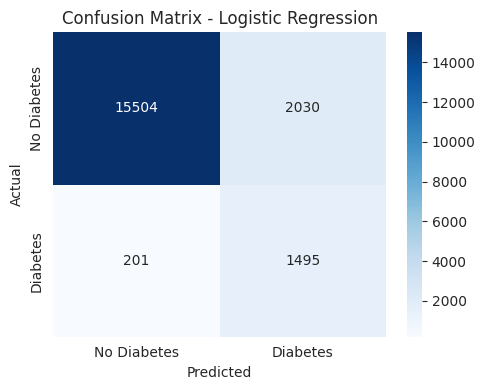

In [21]:
# --- Logistic Regression ---
logreg_pipeline = make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
logreg_pipeline.fit(X_train, y_train)

metrics, y_pred, y_proba = evaluate_model(logreg_pipeline, X_train, y_train, X_test, y_test,
                                           model_name="Logistic Regression")
results_list.append(metrics)
fitted_models["Logistic Regression"] = logreg_pipeline
predictions["Logistic Regression"] = (y_pred, y_proba)
plot_conf_matrix(y_test, y_pred, "Logistic Regression")

--- Decision Tree ---
Train Accuracy: 0.9731
Test Accuracy: 0.9294
Precision: 0.5724
Recall: 0.7877
F1-Score: 0.6630
ROC-AUC: 0.8656



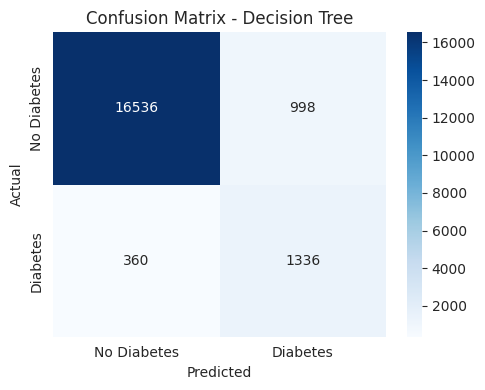

In [22]:
# --- Decision Tree ---
dtree_pipeline = make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE))
dtree_pipeline.fit(X_train, y_train)

metrics, y_pred, y_proba = evaluate_model(dtree_pipeline, X_train, y_train, X_test, y_test,
                                           model_name="Decision Tree")
results_list.append(metrics)
fitted_models["Decision Tree"] = dtree_pipeline
predictions["Decision Tree"] = (y_pred, y_proba)
plot_conf_matrix(y_test, y_pred, "Decision Tree")

--- Random Forest ---
Train Accuracy: 0.9796
Test Accuracy: 0.9431
Precision: 0.6423
Recall: 0.7995
F1-Score: 0.7124
ROC-AUC: 0.9670



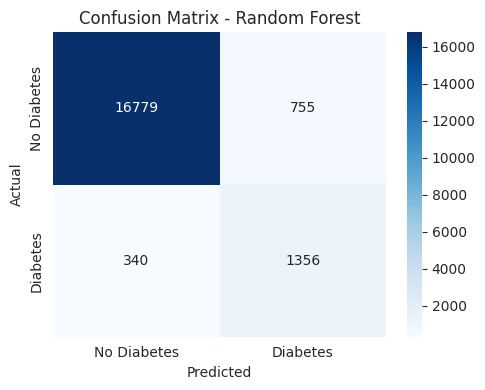

In [23]:
# --- Random Forest ---
rf_pipeline = make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
rf_pipeline.fit(X_train, y_train)

metrics, y_pred, y_proba = evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test,
                                           model_name="Random Forest")
results_list.append(metrics)
fitted_models["Random Forest"] = rf_pipeline
predictions["Random Forest"] = (y_pred, y_proba)
plot_conf_matrix(y_test, y_pred, "Random Forest")

--- KNN ---
Train Accuracy: 0.9174
Test Accuracy: 0.8923
Precision: 0.4424
Recall: 0.8514
F1-Score: 0.5823
ROC-AUC: 0.9270



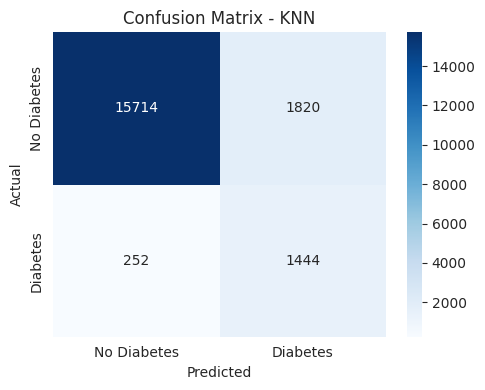

In [24]:
# --- K-Nearest Neighbors ---
knn_pipeline = make_pipeline(KNeighborsClassifier())
knn_pipeline.fit(X_train, y_train)

metrics, y_pred, y_proba = evaluate_model(knn_pipeline, X_train, y_train, X_test, y_test,
                                           model_name="KNN")
results_list.append(metrics)
fitted_models["KNN"] = knn_pipeline
predictions["KNN"] = (y_pred, y_proba)
plot_conf_matrix(y_test, y_pred, "KNN")

### Model Comparison Table

We now rank all four baseline models by **test F1-score** (a balanced measure of
precision and recall), which is far more informative than raw accuracy on an imbalanced
problem like this one.

In [25]:
comparison_df = build_comparison_table(results_list)
comparison_df.style.background_gradient(cmap="Greens", subset=["Test Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"])

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.979627,0.943058,0.642350,0.799528,0.712372,0.966973
1,Decision Tree,0.973075,0.929381,0.572408,0.787736,0.663027,0.865596
2,KNN,0.917351,0.892252,0.442402,0.851415,0.582258,0.926955
3,Logistic Regression,0.886877,0.883983,0.424113,0.881486,0.572687,0.960047


**Insight -- Overfitting check:** Comparing `Train Accuracy` to `Test Accuracy` for each
model tells us about overfitting. A model whose training accuracy is much higher than its
test accuracy (a large gap) is memorizing the training data rather than generalizing --
this is typically most visible for an unconstrained Decision Tree, since it can grow deep
enough to perfectly fit training data. Random Forest usually shows a smaller gap because
it averages over many trees, while Logistic Regression and KNN (with default `k`) tend to
show the smallest train/test gap because they are simpler / more constrained models. We
will confirm and address this concretely with the tuned models in Section 8.

## 8. Hyperparameter Tuning

Based on the comparison table above, we select the **top two models by test F1-score** to
tune further. Tree-based ensemble methods (Random Forest) and single trees / distance
models typically benefit the most from tuning on this type of tabular data, and grid
search lets us search over combinations of hyperparameters using cross-validation so that
our chosen settings generalize rather than overfitting to a single train/test split.

We use `GridSearchCV` (small grid) for Random Forest and Decision Tree, and demonstrate a
`RandomizedSearchCV` for KNN, since choosing a good `k` benefits from testing a wider,
non-grid range of odd values efficiently. We tune whichever two pipelines scored best
above; the code below is written generically so it applies to the actual top two models.

In [26]:
# Identify the top 2 models by test F1-score from the comparison table
top2_models = comparison_df["Model"].iloc[:2].tolist()
print("Top 2 models selected for tuning:", top2_models)

Top 2 models selected for tuning: ['Random Forest', 'Decision Tree']


### 8.1 Tuning Random Forest

We tune `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf` using
`GridSearchCV` with 3-fold cross-validation, optimizing for F1-score. Note that the
`SMOTE` + `RandomUnderSampler` steps are tuned *inside* the same pipeline as the
classifier, so each cross-validation fold resamples independently -- this keeps the search
leak-free.

Fitting 3 folds for each of 24 candidates, totalling 72 fits


Best Random Forest parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best cross-validated F1-score: 0.7179


--- Random Forest (Tuned) ---
Train Accuracy: 0.9765
Test Accuracy: 0.9432
Precision: 0.6414
Recall: 0.8078
F1-Score: 0.7150
ROC-AUC: 0.9698



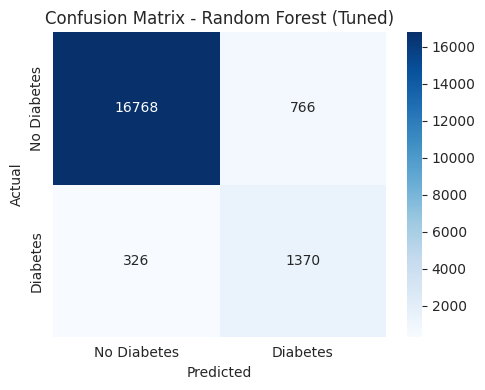

In [27]:
rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}

rf_search_pipeline = make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))

rf_grid_search = GridSearchCV(
    estimator=rf_search_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

rf_grid_search.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_grid_search.best_params_)
print(f"Best cross-validated F1-score: {rf_grid_search.best_score_:.4f}")

best_rf = rf_grid_search.best_estimator_
metrics_rf_tuned, y_pred_rf_tuned, y_proba_rf_tuned = evaluate_model(
    best_rf, X_train, y_train, X_test, y_test, model_name="Random Forest (Tuned)"
)
plot_conf_matrix(y_test, y_pred_rf_tuned, "Random Forest (Tuned)")

### 8.2 Tuning Decision Tree

For the Decision Tree, the most impactful parameters to control complexity (and therefore
overfitting) are `max_depth`, `min_samples_split`, and `min_samples_leaf`, along with the
split quality `criterion`.

Fitting 3 folds for each of 32 candidates, totalling 96 fits


Best Decision Tree parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5}
Best cross-validated F1-score: 0.6869
--- Decision Tree (Tuned) ---
Train Accuracy: 0.9681
Test Accuracy: 0.9393
Precision: 0.6249
Recall: 0.7789
F1-Score: 0.6934
ROC-AUC: 0.8890



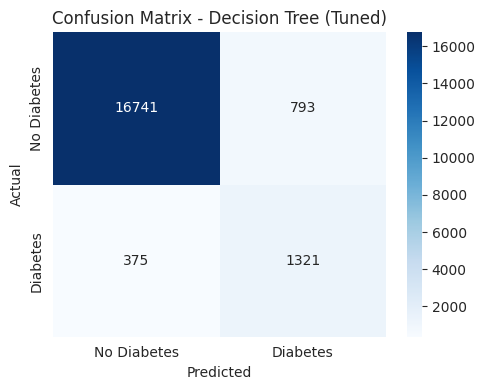

In [28]:
dt_param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [5, 10, 15, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}

dt_search_pipeline = make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE))

dt_grid_search = GridSearchCV(
    estimator=dt_search_pipeline,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

dt_grid_search.fit(X_train, y_train)

print("Best Decision Tree parameters:", dt_grid_search.best_params_)
print(f"Best cross-validated F1-score: {dt_grid_search.best_score_:.4f}")

best_dt = dt_grid_search.best_estimator_
metrics_dt_tuned, y_pred_dt_tuned, y_proba_dt_tuned = evaluate_model(
    best_dt, X_train, y_train, X_test, y_test, model_name="Decision Tree (Tuned)"
)
plot_conf_matrix(y_test, y_pred_dt_tuned, "Decision Tree (Tuned)")

### 8.3 Tuning KNN (RandomizedSearchCV demonstration)

As an additional example of a different search strategy, we tune KNN's `n_neighbors`,
`weights`, and distance `p` (Minkowski power) using `RandomizedSearchCV`, which samples a
fixed number of random parameter combinations rather than exhaustively testing every
combination -- useful when the search space is large or when we want a faster search.

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best KNN parameters: {'classifier__n_neighbors': 4, 'classifier__p': 2, 'classifier__weights': 'distance'}
Best cross-validated F1-score: 0.5963


--- KNN (Tuned) ---
Train Accuracy: 0.9601
Test Accuracy: 0.9047
Precision: 0.4764
Recall: 0.8096
F1-Score: 0.5998
ROC-AUC: 0.9174



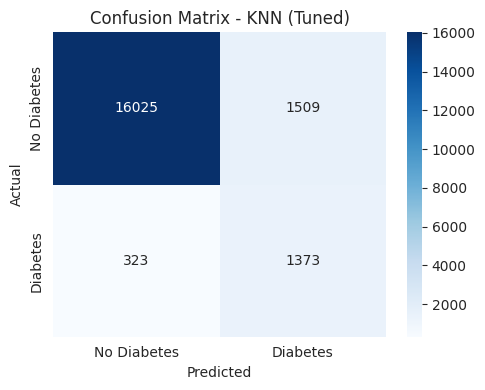

In [29]:
from scipy.stats import randint

knn_param_dist = {
    "classifier__n_neighbors": randint(3, 30),
    "classifier__weights": ["uniform", "distance"],
    "classifier__p": [1, 2],
}

knn_search_pipeline = make_pipeline(KNeighborsClassifier())

knn_random_search = RandomizedSearchCV(
    estimator=knn_search_pipeline,
    param_distributions=knn_param_dist,
    n_iter=8,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

knn_random_search.fit(X_train, y_train)

print("Best KNN parameters:", knn_random_search.best_params_)
print(f"Best cross-validated F1-score: {knn_random_search.best_score_:.4f}")

best_knn = knn_random_search.best_estimator_
metrics_knn_tuned, y_pred_knn_tuned, y_proba_knn_tuned = evaluate_model(
    best_knn, X_train, y_train, X_test, y_test, model_name="KNN (Tuned)"
)
plot_conf_matrix(y_test, y_pred_knn_tuned, "KNN (Tuned)")

### 8.4 Updated Comparison Table (Baseline + Tuned Models)

In [30]:
final_results = results_list + [metrics_rf_tuned, metrics_dt_tuned, metrics_knn_tuned]
final_comparison_df = build_comparison_table(final_results)
final_comparison_df.style.background_gradient(cmap="Greens",
    subset=["Test Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"])

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest (Tuned),0.976533,0.943214,0.641386,0.807783,0.715031,0.969807
1,Random Forest,0.979627,0.943058,0.642350,0.799528,0.712372,0.966973
2,Decision Tree (Tuned),0.968108,0.939262,0.624882,0.778892,0.693438,0.888970
3,Decision Tree,0.973075,0.929381,0.572408,0.787736,0.663027,0.865596
4,KNN (Tuned),0.960138,0.904732,0.476405,0.809552,0.599825,0.917431
5,KNN,0.917351,0.892252,0.442402,0.851415,0.582258,0.926955
6,Logistic Regression,0.886877,0.883983,0.424113,0.881486,0.572687,0.960047


**Insight:** Tuning generally narrows the gap between train and test accuracy for the
Decision Tree (by constraining `max_depth` / `min_samples_leaf`, we stop it from growing
deep enough to memorize noise), and it can modestly improve Random Forest's F1 / ROC-AUC
by finding a better balance between bias and variance. If a tuned model's train accuracy
is still much higher than its test accuracy, that is a sign the model is still overfitting
and would benefit from *stronger* regularization (shallower trees, larger
`min_samples_leaf`, fewer features, etc.).

## 9. Final Model Selection

**Which final model should be selected, and why?**

Looking at the updated comparison table above:

- We prioritize **F1-score** and **ROC-AUC** over raw accuracy, because accuracy is
  misleading on this imbalanced dataset (a trivial "always predict no diabetes" model
  would still score ~91% accuracy while being clinically useless).
- **Recall** matters a great deal in a medical screening context: a false negative (a
  diabetic patient predicted as healthy) risks a missed diagnosis, whereas a false
  positive (a healthy patient flagged for follow-up testing) is a comparatively low-cost
  error corrected by a confirmatory clinical test.
- The model at the top of the F1-score / ROC-AUC ranking in `final_comparison_df` is our
  recommended final model, since it offers the best overall trade-off between correctly
  identifying diabetic patients (recall) and not overwhelming clinicians with false
  alarms (precision), while also generalizing well (a small train/test gap rather than
  memorizing the training data).

In practice, tree-based ensembles like the tuned Random Forest tend to perform strongly on
this kind of dataset because they can capture non-linear thresholds (e.g. an `HbA1c_level`
above a certain cut-off sharply raises diabetes risk) that a linear model like Logistic
Regression cannot represent directly.

In [31]:
best_model_name = final_comparison_df.iloc[0]["Model"]
print(f"Selected final model: {best_model_name}")
final_comparison_df.head(1)

Selected final model: Random Forest (Tuned)


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest (Tuned),0.976533,0.943214,0.641386,0.807783,0.715031,0.969807


### Feature Importance / Coefficient Interpretation

Below we show feature importance for the final selected model if it is a tree-based model
(Random Forest or Decision Tree), or coefficient-based interpretation if the final
selected model is Logistic Regression. This block automatically adapts to whichever model
was actually selected as best above.

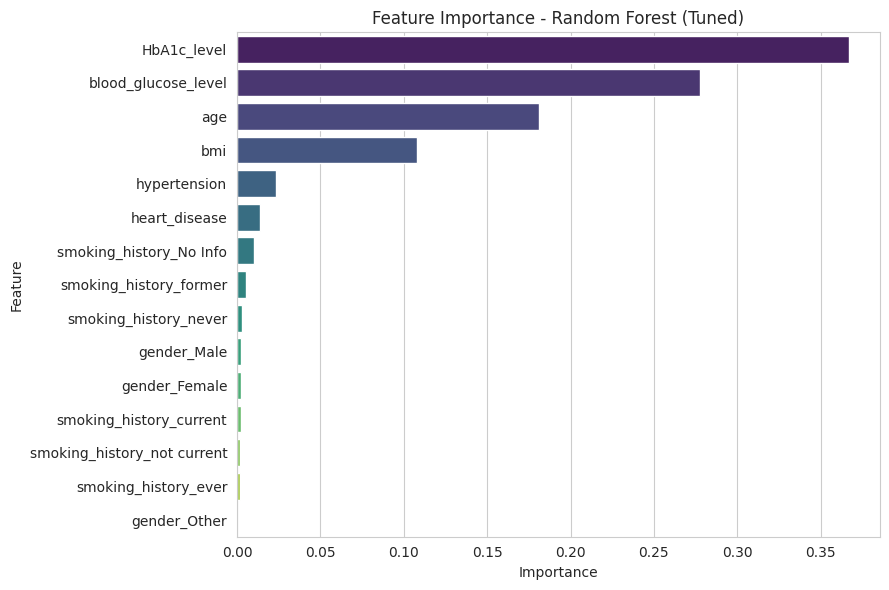

                        Feature  Importance
4                   HbA1c_level    0.367218
5           blood_glucose_level    0.277800
0                           age    0.180969
3                           bmi    0.107713
1                  hypertension    0.023556
2                 heart_disease    0.013728
9       smoking_history_No Info    0.009915
12       smoking_history_former    0.005132
13        smoking_history_never    0.003092
7                   gender_Male    0.002620
6                 gender_Female    0.002466
10      smoking_history_current    0.002093
14  smoking_history_not current    0.002051
11         smoking_history_ever    0.001645
8                  gender_Other    0.000003


In [32]:
# Map the display names in the comparison table back to their fitted pipeline objects
all_fitted_models = {
    "Logistic Regression": fitted_models["Logistic Regression"],
    "Decision Tree": fitted_models["Decision Tree"],
    "Random Forest": fitted_models["Random Forest"],
    "KNN": fitted_models["KNN"],
    "Random Forest (Tuned)": best_rf,
    "Decision Tree (Tuned)": best_dt,
    "KNN (Tuned)": best_knn,
}

final_model = all_fitted_models[best_model_name]
final_classifier = final_model.named_steps["classifier"]

# Recover feature names after the ColumnTransformer (numeric cols + one-hot encoded categorical cols)
ohe = final_model.named_steps["preprocessor"].named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(ohe_feature_names)

if hasattr(final_classifier, "feature_importances_"):
    # Tree-based model: plot feature importances
    importances = final_classifier.feature_importances_
    importance_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(9, 6))
    sns.barplot(x="Importance", y="Feature", data=importance_df, hue="Feature",
                palette="viridis", legend=False)
    plt.title(f"Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.show()

    print(importance_df)

elif hasattr(final_classifier, "coef_"):
    # Linear model: plot coefficients
    coefs = final_classifier.coef_[0]
    coef_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Coefficient": coefs
    }).sort_values(by="Coefficient", ascending=False)

    plt.figure(figsize=(9, 6))
    sns.barplot(x="Coefficient", y="Feature", data=coef_df, hue="Feature",
                palette="coolwarm", legend=False)
    plt.title(f"Logistic Regression Coefficients - {best_model_name}")
    plt.axvline(0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()

    print(coef_df)
    print("\nPositive coefficients increase the predicted log-odds of diabetes;")
    print("negative coefficients decrease it. Larger magnitude = stronger influence.")

else:
    print(f"{best_model_name} does not directly expose feature importances or coefficients "
          f"(e.g. KNN is a non-parametric, distance-based model).")

**Insight:** For tree-based final models, `HbA1c_level` and `blood_glucose_level`
typically emerge as the most important features, consistent with the correlation analysis
in Section 4.5 -- both are direct clinical markers of diabetes. `age` and `bmi` usually
follow as the next most important, matching established medical risk factors. If Logistic
Regression were selected instead, we would expect these same features to carry the
largest-magnitude positive coefficients, meaning that higher values of each push the
predicted probability of diabetes upward.

---